# DRC Violation task experiment

### Baseline configuration
* max iterations: 15000, number of epochs: 150
* in/out channels: 9, 1
* threshold: 0.1 (this parameters is used to create the confusion matrix to calculate metrics)

In [27]:
# Imports
import pandas as pd
import os
import numpy as np
from aim.storage.context import Context
from aim import Repo
import matplotlib.pyplot as plt

# Basic utils
repo = Repo(path=os.getcwd())

def get_runs_by_experiment_name(experiment_name: str):
    query = ''
    query += ' run.active == False and'
    query += ' run.archived == False'
    query += f' and run.experiment == "{experiment_name}"'

    runs = repo.query_runs(query=query, report_mode=0)
    return runs.iter_runs()

def return_metrics_sorted(run, name, subset='global'):
    metric = run.get_metric(name, context=Context({'subset': subset}))
    ts = metric.timestamps.values_numpy()
    vals = metric.values.values_numpy()
    idx = np.argsort(ts)
    vals = vals[idx]
    return vals

def get_single_value_metric(run, name, subset='global'):
    metric = run.get_metric(name, context=Context({'subset': subset}))
    return metric.values.values_numpy()[0]

def get_hist_data_for_distribution(run, name):
    sequences_info = run.collect_sequence_info(sequence_types=['distributions'])
    if 'distributions' in sequences_info:
        for dist_info in sequences_info['distributions']:
            if dist_info['name'] == name:
                last = dist_info['values']['last']
                return last.to_np_histogram()

def plot_histograms(histograms_data, title=None, unit='GB'):
    items = [(k, v) for k, v in histograms_data.items() if v is not None]
    if not items:
        return

    fig, axes = plt.subplots(1, len(items), figsize=(5 * len(items), 4), constrained_layout=True)
    if len(items) == 1:
        axes = [axes]

    for ax, (name, (counts, _)) in zip(axes, items):


        ax.hist(counts, bins=30, edgecolor='black', alpha=0.7)
        ax.set_title(name)
        ax.set_xlabel(unit)
        ax.set_ylabel(name)

        ax.text(
            0.98,
            0.98,
            f"mean={np.mean(counts):.4f} {unit}\nstd={np.std(counts):.4f} {unit}",
            transform=ax.transAxes,
            ha='right',
            va='top',
            fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='0.7'),
        )

    if title:
        fig.suptitle(title)

    plt.show()

## Train results
Print the configuration we used

In [28]:
train_runs = get_runs_by_experiment_name('drc_centralized_train')

train_conf_table_content = []
id = 1
for run in train_runs:
    run = run.run 
    hparams = run.get('hparams')

    conf_dict = {
        'tag': run.tags[0],
        'batch_size': hparams['batch_size'],
        'eval_metrics': hparams['eval_metric'],
        'loss_type': hparams['loss_type'],
        'lr': hparams['lr'],
        'threshold': hparams['threshold'],
        'weight_decay': hparams['weight_decay']
    }

    id += 1
    train_conf_table_content.append(conf_dict)

train_conf_df = pd.DataFrame(train_conf_table_content)
display(train_conf_df)

,tag,batch_size,eval_metrics,loss_type,lr,threshold,weight_decay
0,"Biased Loss (s=20, b=0.4)",8,"[NRMS, SSIM]",BiasedMSELoss,0.00020,0.1,0.0001
1,high_weight_decay,8,"[NRMS, SSIM]",MSELoss,0.00005,0.1,0.0010
2,high_lr_bs,16,"[NRMS, SSIM]",MSELoss,0.00100,0.1,0.0001
3,L1_loss,8,"[NRMS, SSIM]",L1Loss,0.00020,0.1,0.0001
4,Baseline,8,"[NRMS, SSIM]",MSELoss,0.00020,0.1,0.0001


## Train results graphs (epoch loss and pixel loss per iteration)

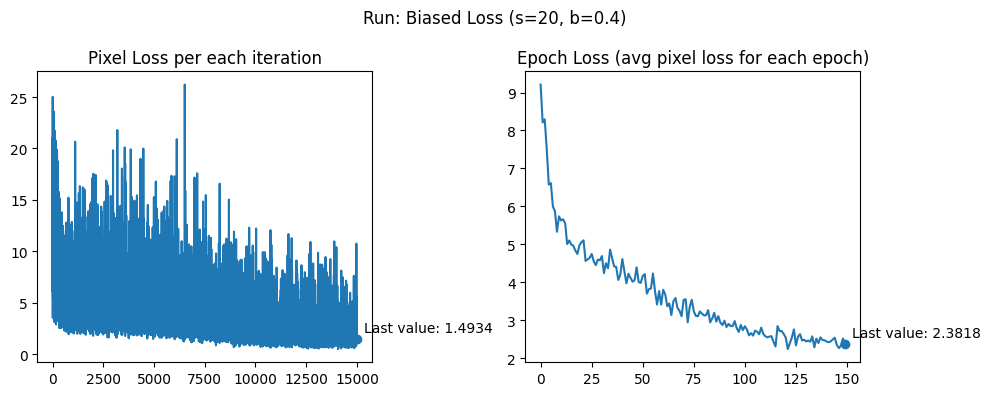

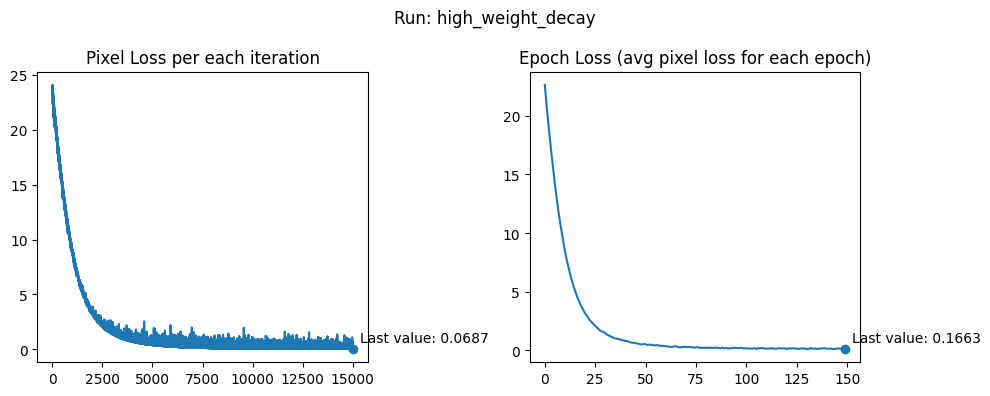

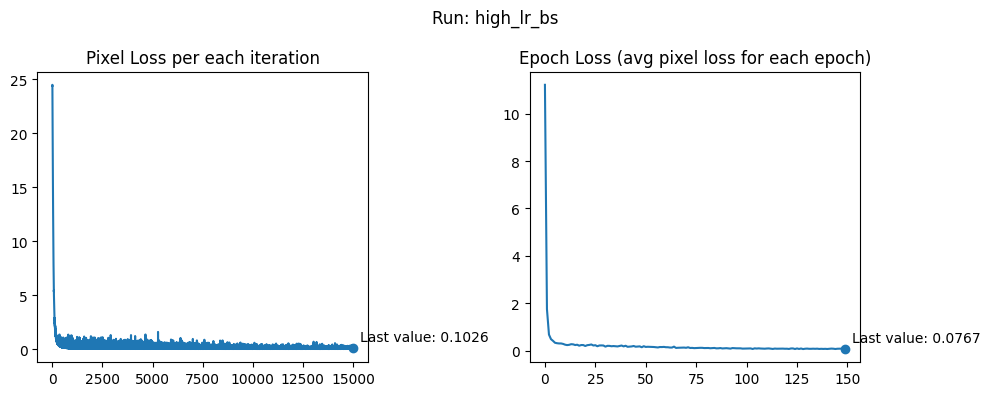

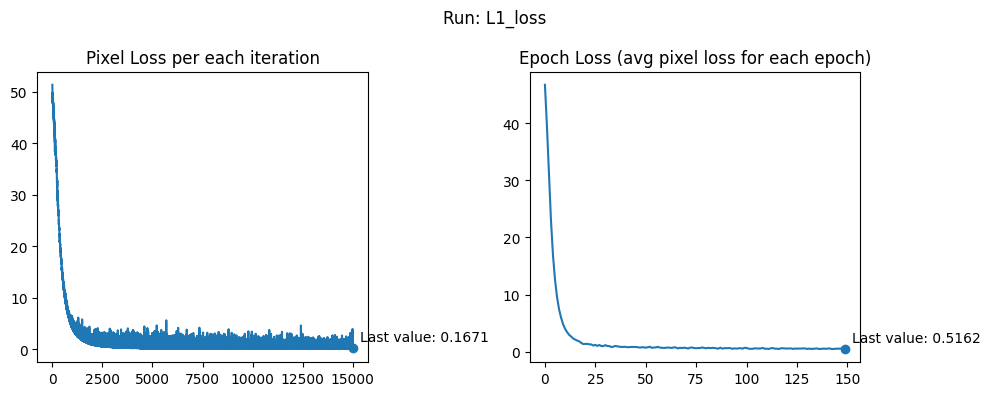

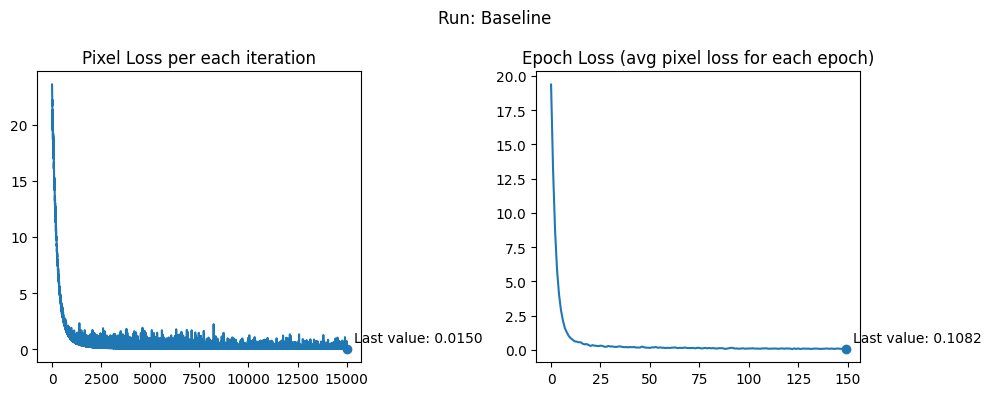

,tag,pixel_loss,epoch_loss
0,"Biased Loss (s=20, b=0.4)",1.493388,2.381795
1,high_weight_decay,0.068691,0.166294
2,high_lr_bs,0.102639,0.076746
3,L1_loss,0.167109,0.516245
4,Baseline,0.015046,0.108233


In [29]:
train_runs = get_runs_by_experiment_name('drc_centralized_train')
loss_table_content = []

for run in train_runs:
    pixel_loss_vals = return_metrics_sorted(run.run, 'Pixel Loss')
    epoch_loss_vals = return_metrics_sorted(run.run, 'Epoch Loss')

    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    plt.suptitle(f"Run: {run.run.tags[0]}")

    # --- First plot ---
    axes[0].plot(pixel_loss_vals)
    axes[0].set_title("Pixel Loss per each iteration")

    best_val_0 = pixel_loss_vals[-1]
    best_idx_0 = len(pixel_loss_vals) - 1

    axes[0].scatter(best_idx_0, best_val_0)
    axes[0].annotate(
        f"Last value: {best_val_0:.4f}",
        (best_idx_0, best_val_0),
        textcoords="offset points",
        xytext=(5, 5)
    )

    # --- Second plot ---
    axes[1].plot(epoch_loss_vals)
    axes[1].set_title("Epoch Loss (avg pixel loss for each epoch)")

    best_idx_1 = len(epoch_loss_vals) - 1
    best_val_1 = epoch_loss_vals[-1]

    axes[1].scatter(best_idx_1, best_val_1)
    axes[1].annotate(
        f"Last value: {best_val_1:.4f}",
        (best_idx_1, best_val_1),
        textcoords="offset points",
        xytext=(5, 5)
    )

    plt.tight_layout()
    plt.show()

    loss_table_content.append({
        'tag': run.run.tags[0],
        'pixel_loss': pixel_loss_vals[-1],
        'epoch_loss': epoch_loss_vals[-1]
    })

display(pd.DataFrame(loss_table_content))
    

### Train validation results per epoch

,tag,last validation NRMS,last validation SSIM
0,"Biased Loss (s=20, b=0.4)",1.631248,0.169543
1,high_weight_decay,0.441312,0.354832
2,high_lr_bs,0.116943,0.917171
3,L1_loss,0.048185,0.950444
4,Baseline,0.170351,0.829602


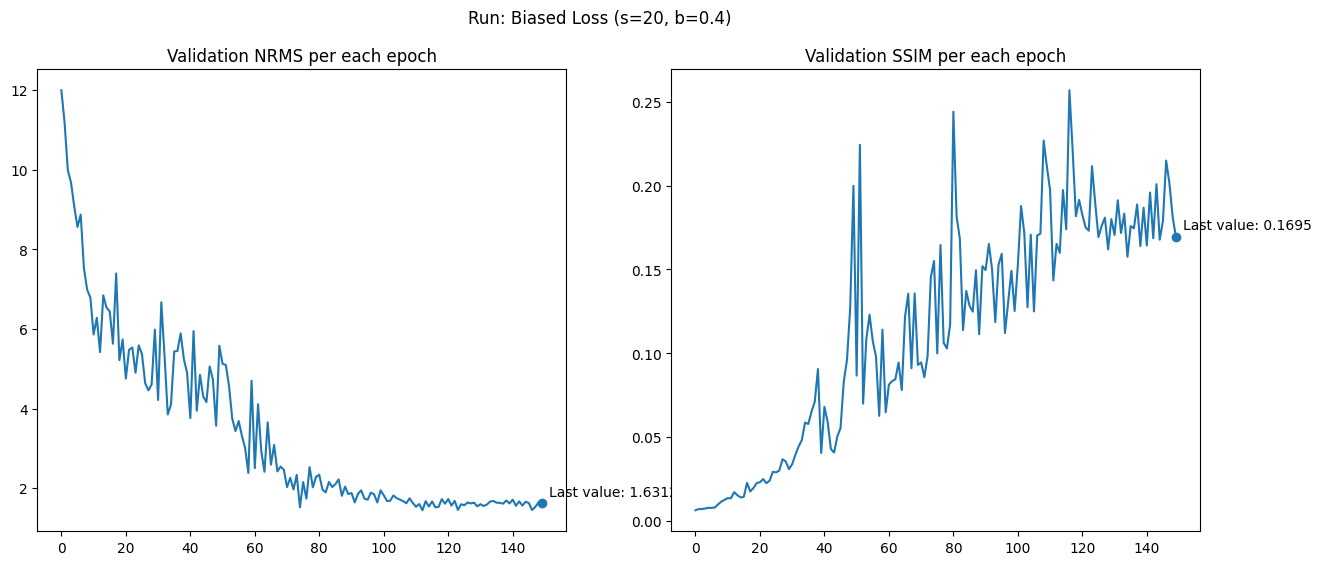

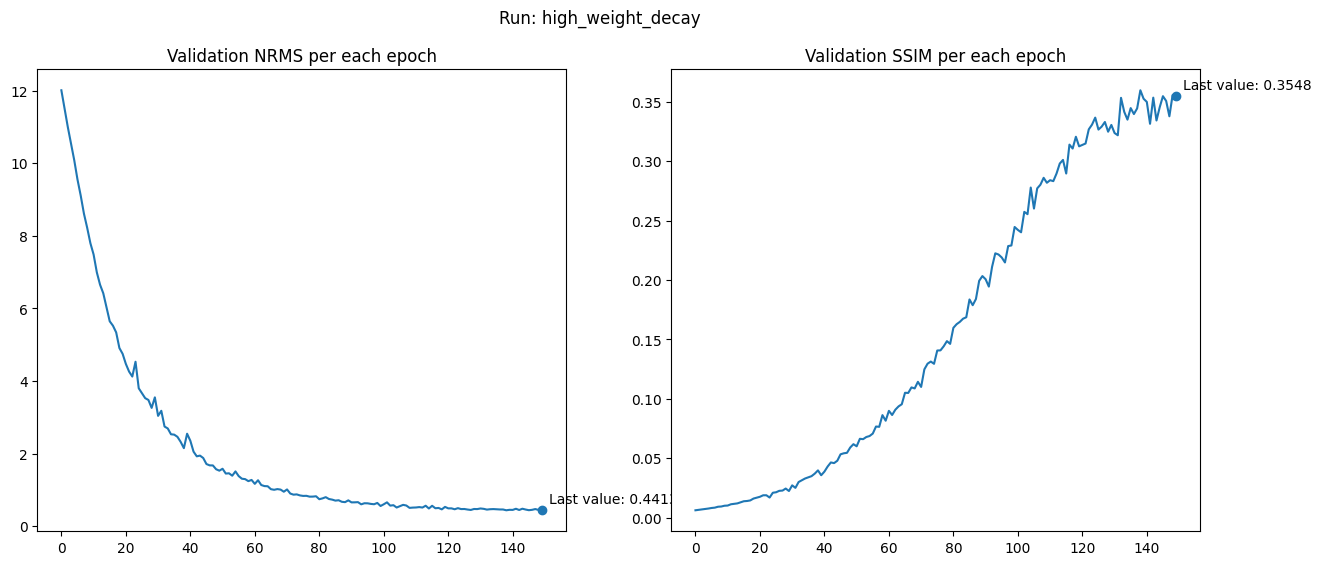

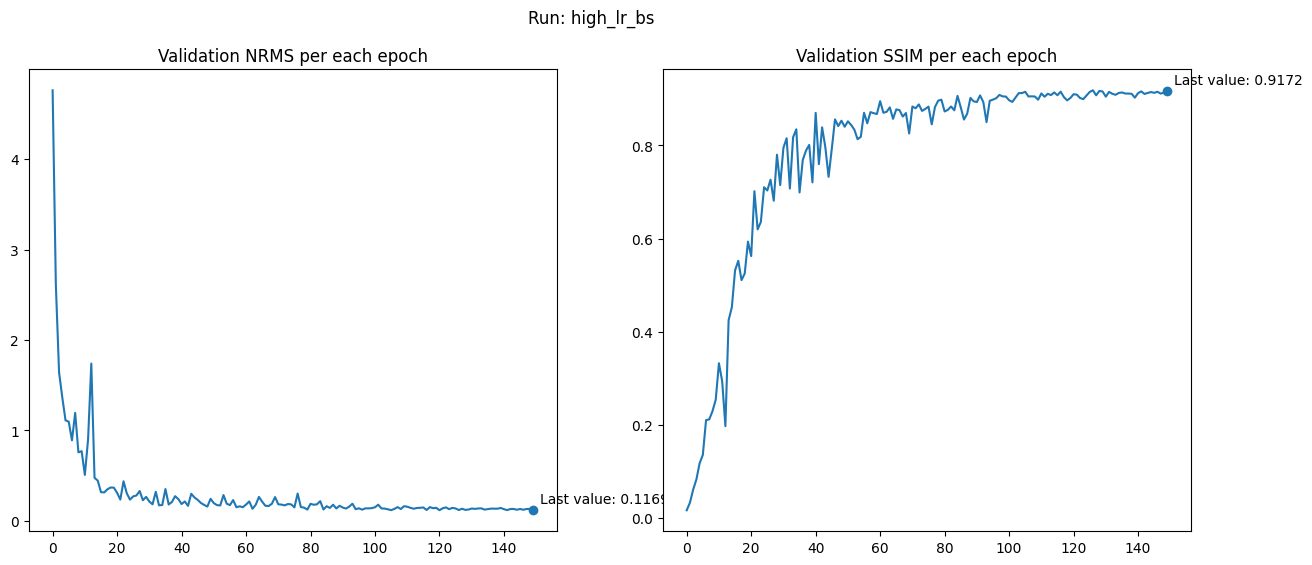

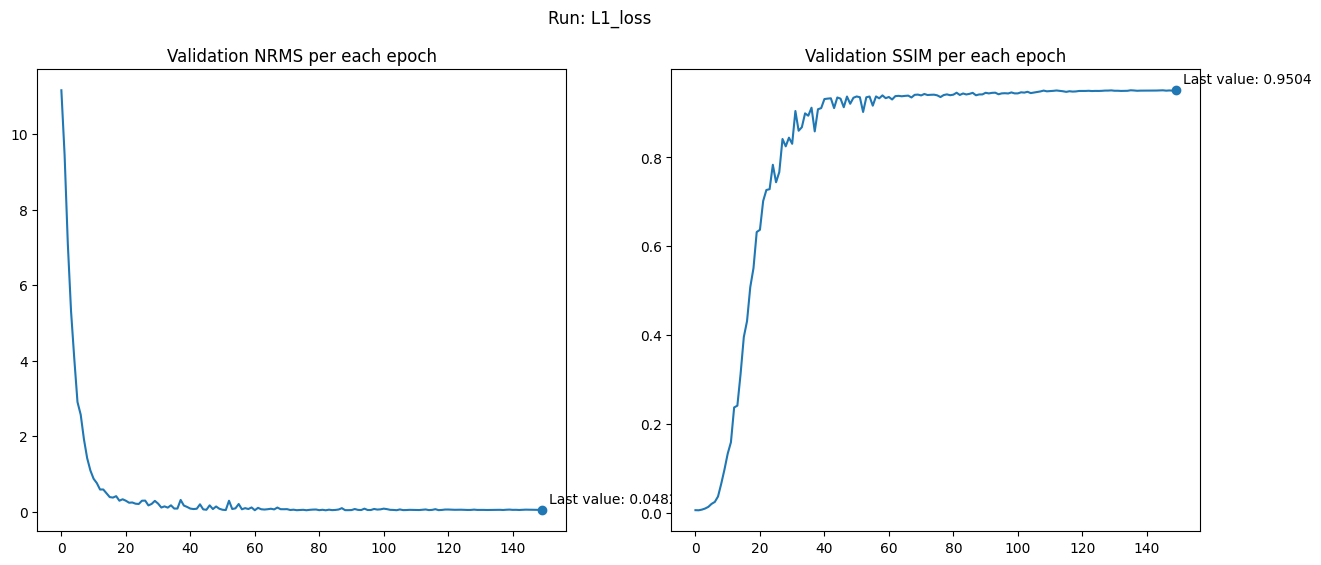

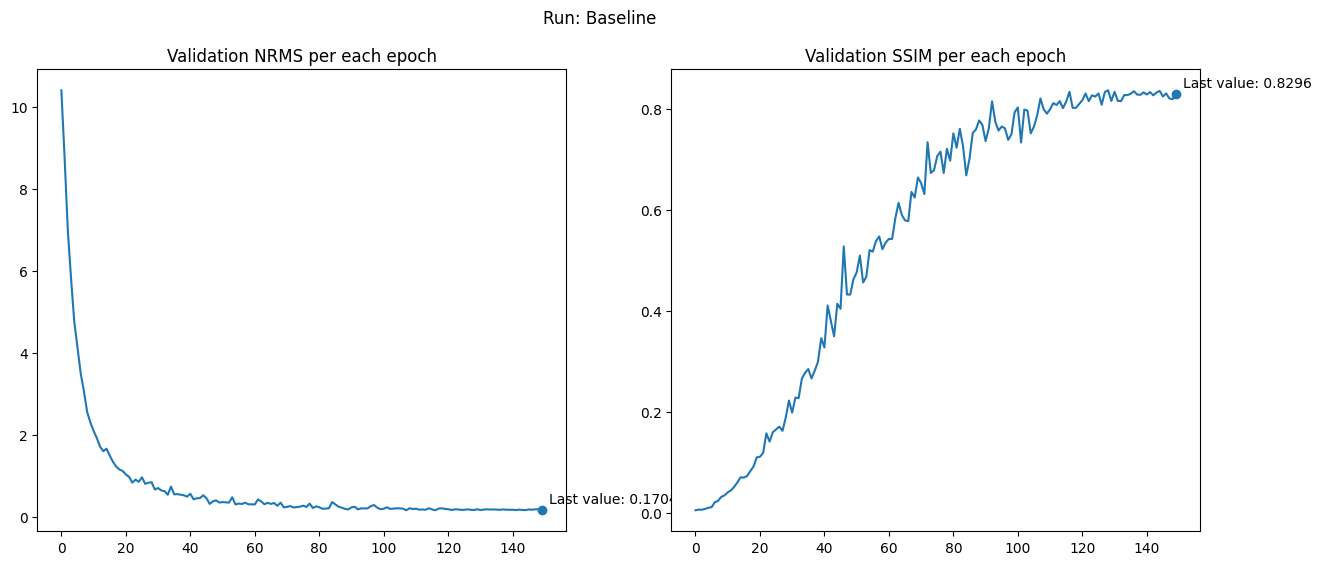

In [30]:
train_runs = get_runs_by_experiment_name('drc_centralized_train')
validate_table_content = []

for run in train_runs:
    run = run.run 
    hparams = run.get('hparams')

    eval_metric = hparams['eval_metric']
    validate_dict = {
        'tag': run.tags[0]
    }

    fig, axes = plt.subplots(len(eval_metric) // 2 + len(eval_metric) % 2, 2, figsize=(15, 6 * (len(eval_metric) // 2 + len(eval_metric) % 2)))
    axes = axes.flatten()
    plt.suptitle(f"Run: {run.tags[0]}")
    for i, metric in enumerate(eval_metric):
        metric_values = return_metrics_sorted(run, f"Val {metric}", subset='val')
        axes[i].plot(metric_values)
        axes[i].set_title(f"Validation {metric} per each epoch")

        best_val = metric_values[-1]
        best_idx = len(metric_values) - 1

        axes[i].scatter(best_idx, best_val)
        axes[i].annotate(
            f"Last value: {best_val:.4f}",
            (best_idx, best_val),
            textcoords="offset points",
            xytext=(5, 5)
        )
        validate_dict[f"last validation {metric}"] = best_val
        

    validate_table_content.append(validate_dict)

display(pd.DataFrame(validate_table_content))

### Test results distribution (metrics)

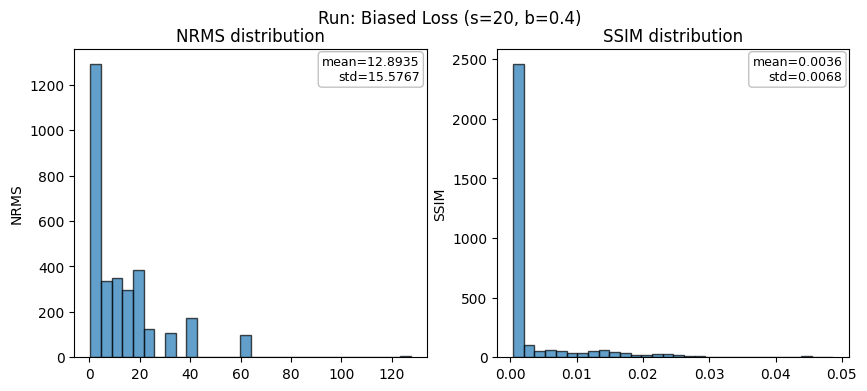

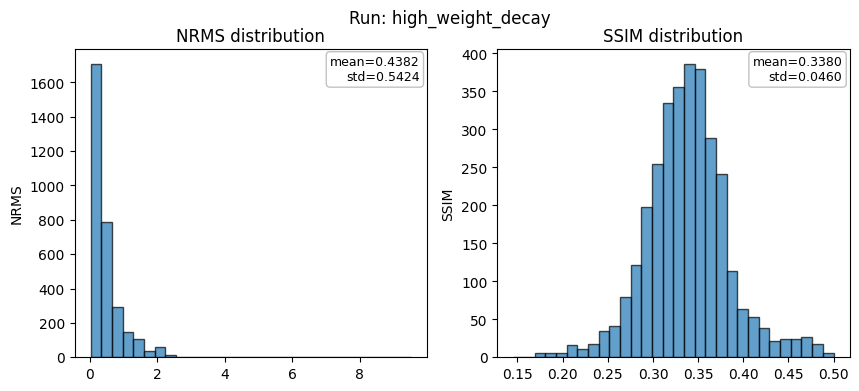

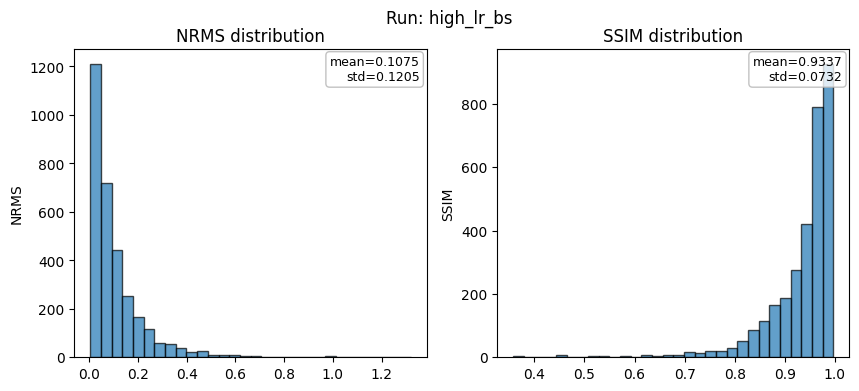

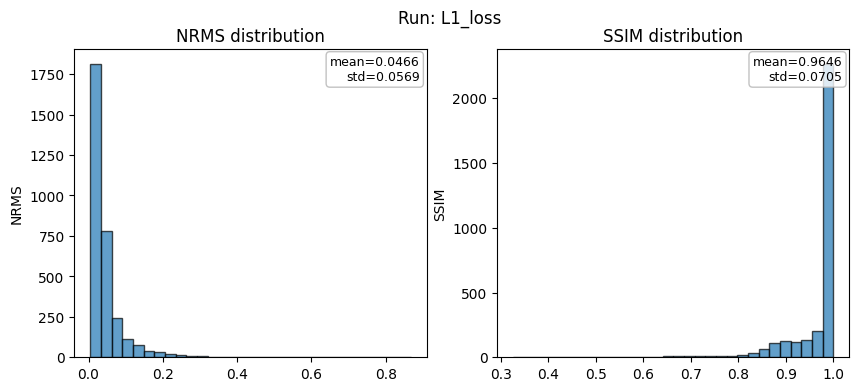

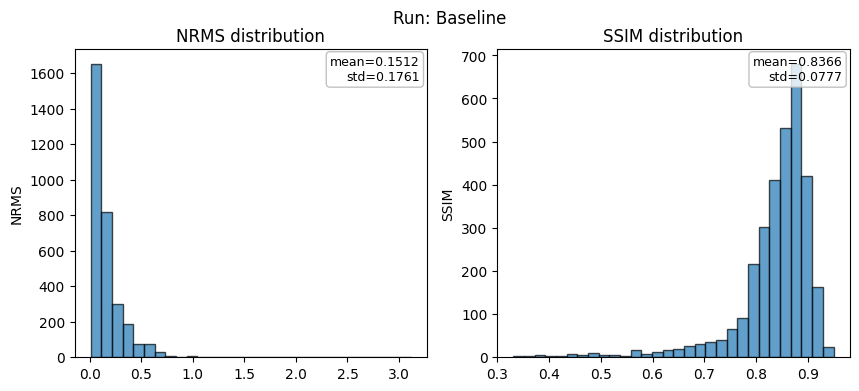

In [31]:
for run in get_runs_by_experiment_name('drc_centralized_test'):
    run = run.run
    nrms = run.get_metric("Test NRMS (dist)", context=Context({'subset': 'test', 'aggregation': 'distribution'}))
    ssim = run.get_metric("Test SSIM (dist)", context=Context({'subset': 'test', 'aggregation': 'distribution'}))

    histogram_data = {
        'NRMS': nrms.values.values_numpy() if nrms is not None else [],
        'SSIM': ssim.values.values_numpy() if ssim is not None else [],   
    }

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    plt.suptitle(f"Run: {run.tags[0]}")
    axes[0].hist(histogram_data['NRMS'], bins=30, edgecolor='black', alpha=0.7)
    axes[0].set_title("NRMS distribution")
    axes[0].set_xlabel('')
    axes[0].set_ylabel('NRMS')
    axes[0].text(
        0.98,
        0.98,
        f"mean={np.mean(histogram_data['NRMS']):.4f}\nstd={np.std(histogram_data['NRMS']):.4f}",
        transform=axes[0].transAxes,
        ha='right',
        va='top',
        fontsize=9,        
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='0.7'),
    )

    axes[1].hist(histogram_data['SSIM'], bins=30, edgecolor='black', alpha=0.7)
    axes[1].set_title("SSIM distribution")
    axes[1].set_xlabel('')
    axes[1].set_ylabel('SSIM')
    axes[1].text(
        0.98,
        0.98,
        f"mean={np.mean(histogram_data['SSIM']):.4f}\nstd={np.std(histogram_data['SSIM']):.4f}",
        transform=axes[1].transAxes,
        ha='right',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='0.7'),
    )

    plt.show()
    plt.close()
    

### Test results distribution (ROC)

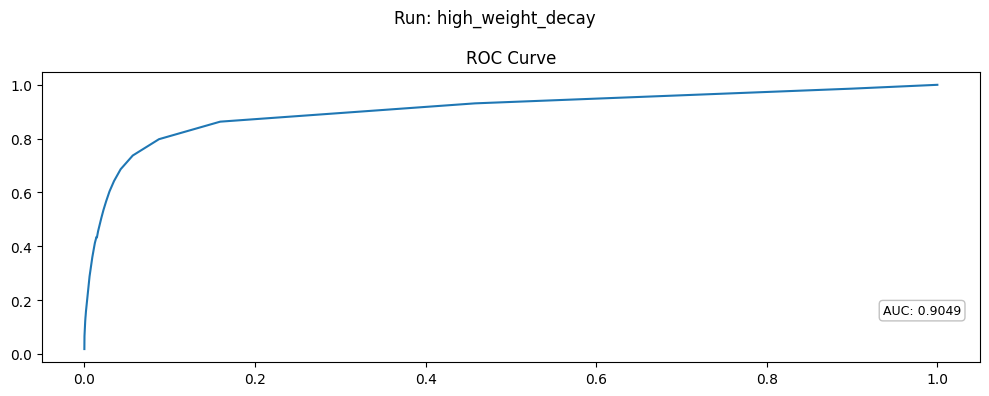

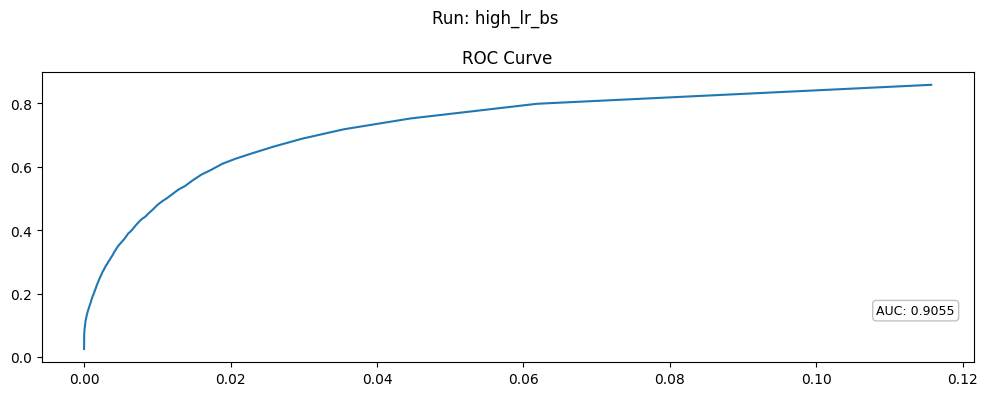

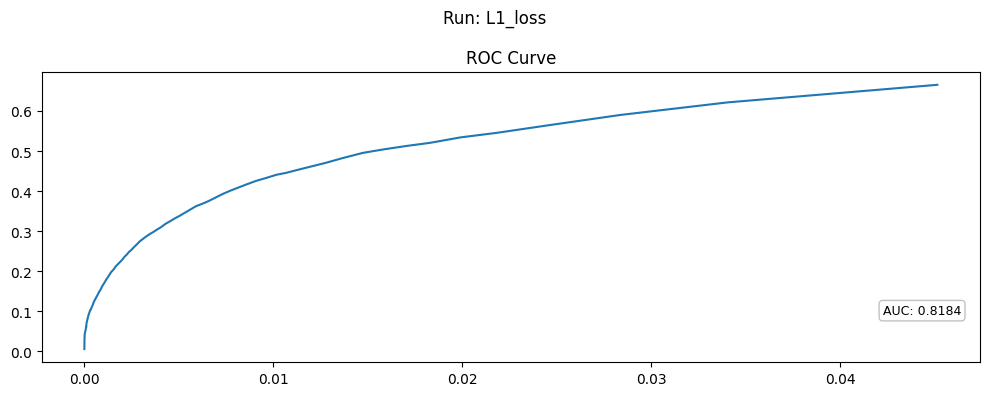

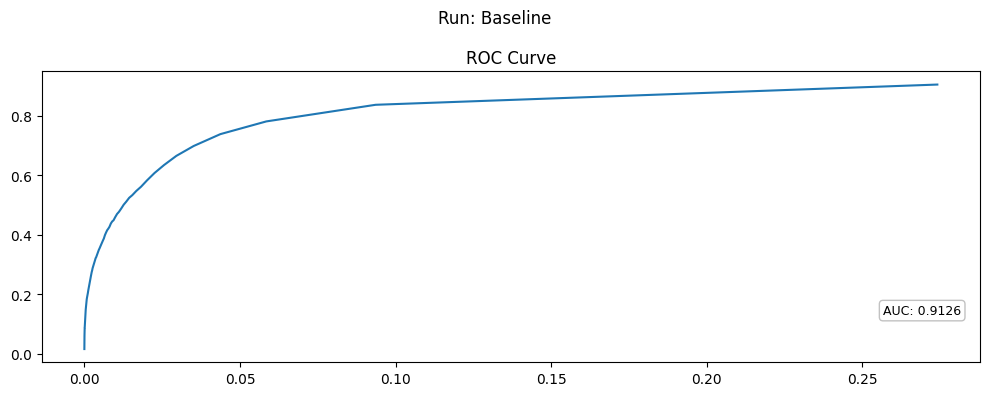

In [32]:
for run in get_runs_by_experiment_name('drc_centralized_test'):
    run = run.run

    metric = run.get_metric("ROC_TPR", context=Context({'type': 'curve'}))
    if metric is not None:
        ts = metric.timestamps.values_numpy()
        vals = metric.values.values_numpy()
        idx = np.argsort(ts)
        vals_tpr = vals[idx]

        metric = run.get_metric("ROC_FPR", context=Context({'type': 'curve'}))
        ts = metric.timestamps.values_numpy()
        vals = metric.values.values_numpy()
        idx = np.argsort(ts)
        vals_fpr = vals[idx]

        fig, axes = plt.subplots(1, 1, figsize=(10, 4))
        plt.suptitle(f"Run: {run.tags[0]}")
        axes.plot(vals_fpr[:-2], vals_tpr[:-2])
        axes.set_title("ROC Curve")
        
        area = 0
        for i in range(1, len(vals_fpr)):
            area += (vals_fpr[i] - vals_fpr[i-1]) * (vals_tpr[i] + vals_tpr[i-1]) / 2
            
        axes.text(
            0.98,
            0.2,
            f"AUC: {area:.4f}",
            transform=axes.transAxes,
            ha='right',
            va='top',
            fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='0.7'),
        )

        plt.tight_layout()
        plt.show()
        plt.close()

### Test final table results

In [ ]:
table_of_content = []
for run in get_runs_by_experiment_name('drc_centralized_test'):
    run = run.run
    nrms = run.get_metric("Test NRMS (dist)", context=Context({'subset': 'test', 'aggregation': 'distribution'}))
    ssim = run.get_metric("Test SSIM (dist)", context=Context({'subset': 'test', 'aggregation': 'distribution'}))

    metric_tpr = run.get_metric("ROC_TPR", context=Context({'type': 'curve'}))
    metric_fpr = run.get_metric("ROC_FPR", context=Context({'type': 'curve'}))

    area = None
    tpr_at_fpr_5 = None

    if metric_tpr is not None and metric_fpr is not None:
        ts_tpr = metric_tpr.timestamps.values_numpy()
        vals_tpr = metric_tpr.values.values_numpy()
        tpr = vals_tpr[np.argsort(ts_tpr)]

        ts_fpr = metric_fpr.timestamps.values_numpy()
        vals_fpr = metric_fpr.values.values_numpy()
        fpr = vals_fpr[np.argsort(ts_fpr)]

        sort_idx = np.argsort(fpr)
        fpr_sorted = fpr[sort_idx]
        tpr_sorted = tpr[sort_idx]

        area = 0
        for i in range(1, len(fpr_sorted)):
            area += (fpr_sorted[i] - fpr_sorted[i-1]) * (tpr_sorted[i] + tpr_sorted[i-1]) / 2

        target_fpr = 0.05
        if len(fpr_sorted) > 0:
            tpr_at_fpr_5 = float(np.interp(target_fpr, fpr_sorted, tpr_sorted))

    metric_acc = run.get_metric("Test Accuracy", context=Context({'subset': 'test'}))
    accuracy = metric_acc.values.values_numpy()[0] if metric_acc is not None else None

    table_of_content.append({
        'Tag': run.tags[0],
        'Avg NRMS': np.mean(nrms.values.values_numpy() if nrms is not None else []),
        'Avg SSIM': np.mean(ssim.values.values_numpy() if ssim is not None else []),
        'AUC ROC': area,
        'TPR @ FPR=5%': tpr_at_fpr_5,
        'accuracy': accuracy,
    })

display(pd.DataFrame(table_of_content))
